In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/joetheguide/evaluate-llms-for-rare-disease-diagnosis/Evaluation.csv


## LOAD DATA

In [2]:


import os, re, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


class Config:
    DATA_PATH = "/kaggle/input/datasets/joetheguide/evaluate-llms-for-rare-disease-diagnosis/Evaluation.csv"
    MIN_SAMPLES_PER_DISEASE = 5
    TFIDF_MAX_FEATURES = 1000
    TEST_SIZE = 0.2
    RANDOM_STATE = 42

config = Config()
print(f"Analysis Date: {datetime.now().strftime('%B %d, %Y')}")


df = pd.read_csv(config.DATA_PATH)
df = df.drop_duplicates(subset=['CaseSummary','Disease'])
df = df[['CaseSummary','Disease','Synonyms','ICD-10','ICD-11','OMIM','GARD','UMLS']].copy()
print(f"Dataset shape: {df.shape}")



Analysis Date: March 10, 2026
Dataset shape: (6915, 8)


## DATA CLEANING & PREPROCESSING

In [3]:

df['CaseSummary'] = df['CaseSummary'].fillna('')
df['clean_text'] = df['CaseSummary'].str.lower().str.replace(r"[^a-z ]"," ",regex=True)


## TEXT STATISTICS

In [4]:
df['summary_length'] = df['CaseSummary'].str.len()
df['summary_words'] = df['CaseSummary'].str.split().str.len()
df['summary_sentences'] = df['CaseSummary'].str.split('[.!?]').str.len()
print(f"Avg words per case: {df['summary_words'].mean():.1f}")
print(f"Median words per case: {df['summary_words'].median():.1f}")
print(f"Max words: {df['summary_words'].max():,}")

Avg words per case: 346.1
Median words per case: 264.0
Max words: 6,583


## DISEASE ANALYSIS

In [5]:
print(f"Unique diseases: {df['Disease'].nunique()}")
top_diseases = df['Disease'].value_counts().head(20)
print("Top 20 diseases:")
print(top_diseases)

# Disease prevalence categories
disease_counts = df['Disease'].value_counts()
prevalence_cats = {
    'Very rare (1 case)': (disease_counts == 1).sum(),
    'Rare (2-5 cases)': ((disease_counts >= 2) & (disease_counts <= 5)).sum(),
    'Uncommon (6-20 cases)': ((disease_counts >= 6) & (disease_counts <= 20)).sum(),
    'Common (21-100 cases)': ((disease_counts >= 21) & (disease_counts <= 100)).sum(),
    'Very common (>100 cases)': (disease_counts > 100).sum()
}
print("Disease prevalence categories:")
for k,v in prevalence_cats.items(): print(f"  {k}: {v}")


Unique diseases: 1012
Top 20 diseases:
Disease
Congenital anomaly of hepatic vein                                   109
Microlissencephaly                                                    92
CACH syndrome                                                         89
Neuroendocrine neoplasm                                               79
Sarcoidosis                                                           76
Non-Hodgkin lymphoma                                                  75
Differentiated thyroid carcinoma                                      66
Nodular lymphocyte predominant Hodgkin lymphoma                       65
Microcephalic osteodysplastic primordial dwarfism types I and III     62
Viral hemorrhagic fever                                               62
Amyloidosis                                                           59
Osteosarcoma                                                          55
Diffuse large B-cell lymphoma                                         55
Mult

## CODE ANALYSIS

In [6]:
code_columns = ['ICD-10','ICD-11','OMIM','GARD','UMLS']
df['code_completeness'] = sum(df[code].notna().astype(int) for code in code_columns if code in df.columns)
print(f"Code completeness (cases with ≥1 code): {(df['code_completeness']>0).sum():,}")


Code completeness (cases with ≥1 code): 6,915


## SYNONYM ANALYSIS

In [7]:
if 'Synonyms' in df.columns:
    df['synonym_count'] = df['Synonyms'].fillna('').str.split(';').str.len()
    df['has_synonyms'] = (df['synonym_count']>0).astype(int)
    print(f"Diseases with synonyms: {df['has_synonyms'].sum():,} ({df['has_synonyms'].mean()*100:.1f}%)")


Diseases with synonyms: 6,915 (100.0%)


## DEMOGRAPHIC EXTRACTION

In [8]:

def extract_age(text):
    patterns = [r'(\d+)[-\s]?year[-\s]?old', r'age\s+(\d+)', r'at\s+the\s+age\s+of\s+(\d+)']
    text = str(text).lower()
    for p in patterns:
        m = re.findall(p,text)
        if m: return int(m[0])
    return np.nan




def extract_gender(text):
    text = str(text).lower()
    if any(w in text for w in ['female','woman','girl','she','her']): return 'Female'
    if any(w in text for w in ['male','man','boy','he','his']): return 'Male'
    return 'Unknown'

df['patient_age'] = df['CaseSummary'].apply(extract_age)
df['patient_gender'] = df['CaseSummary'].apply(extract_gender)

## VISUALIZATIONS

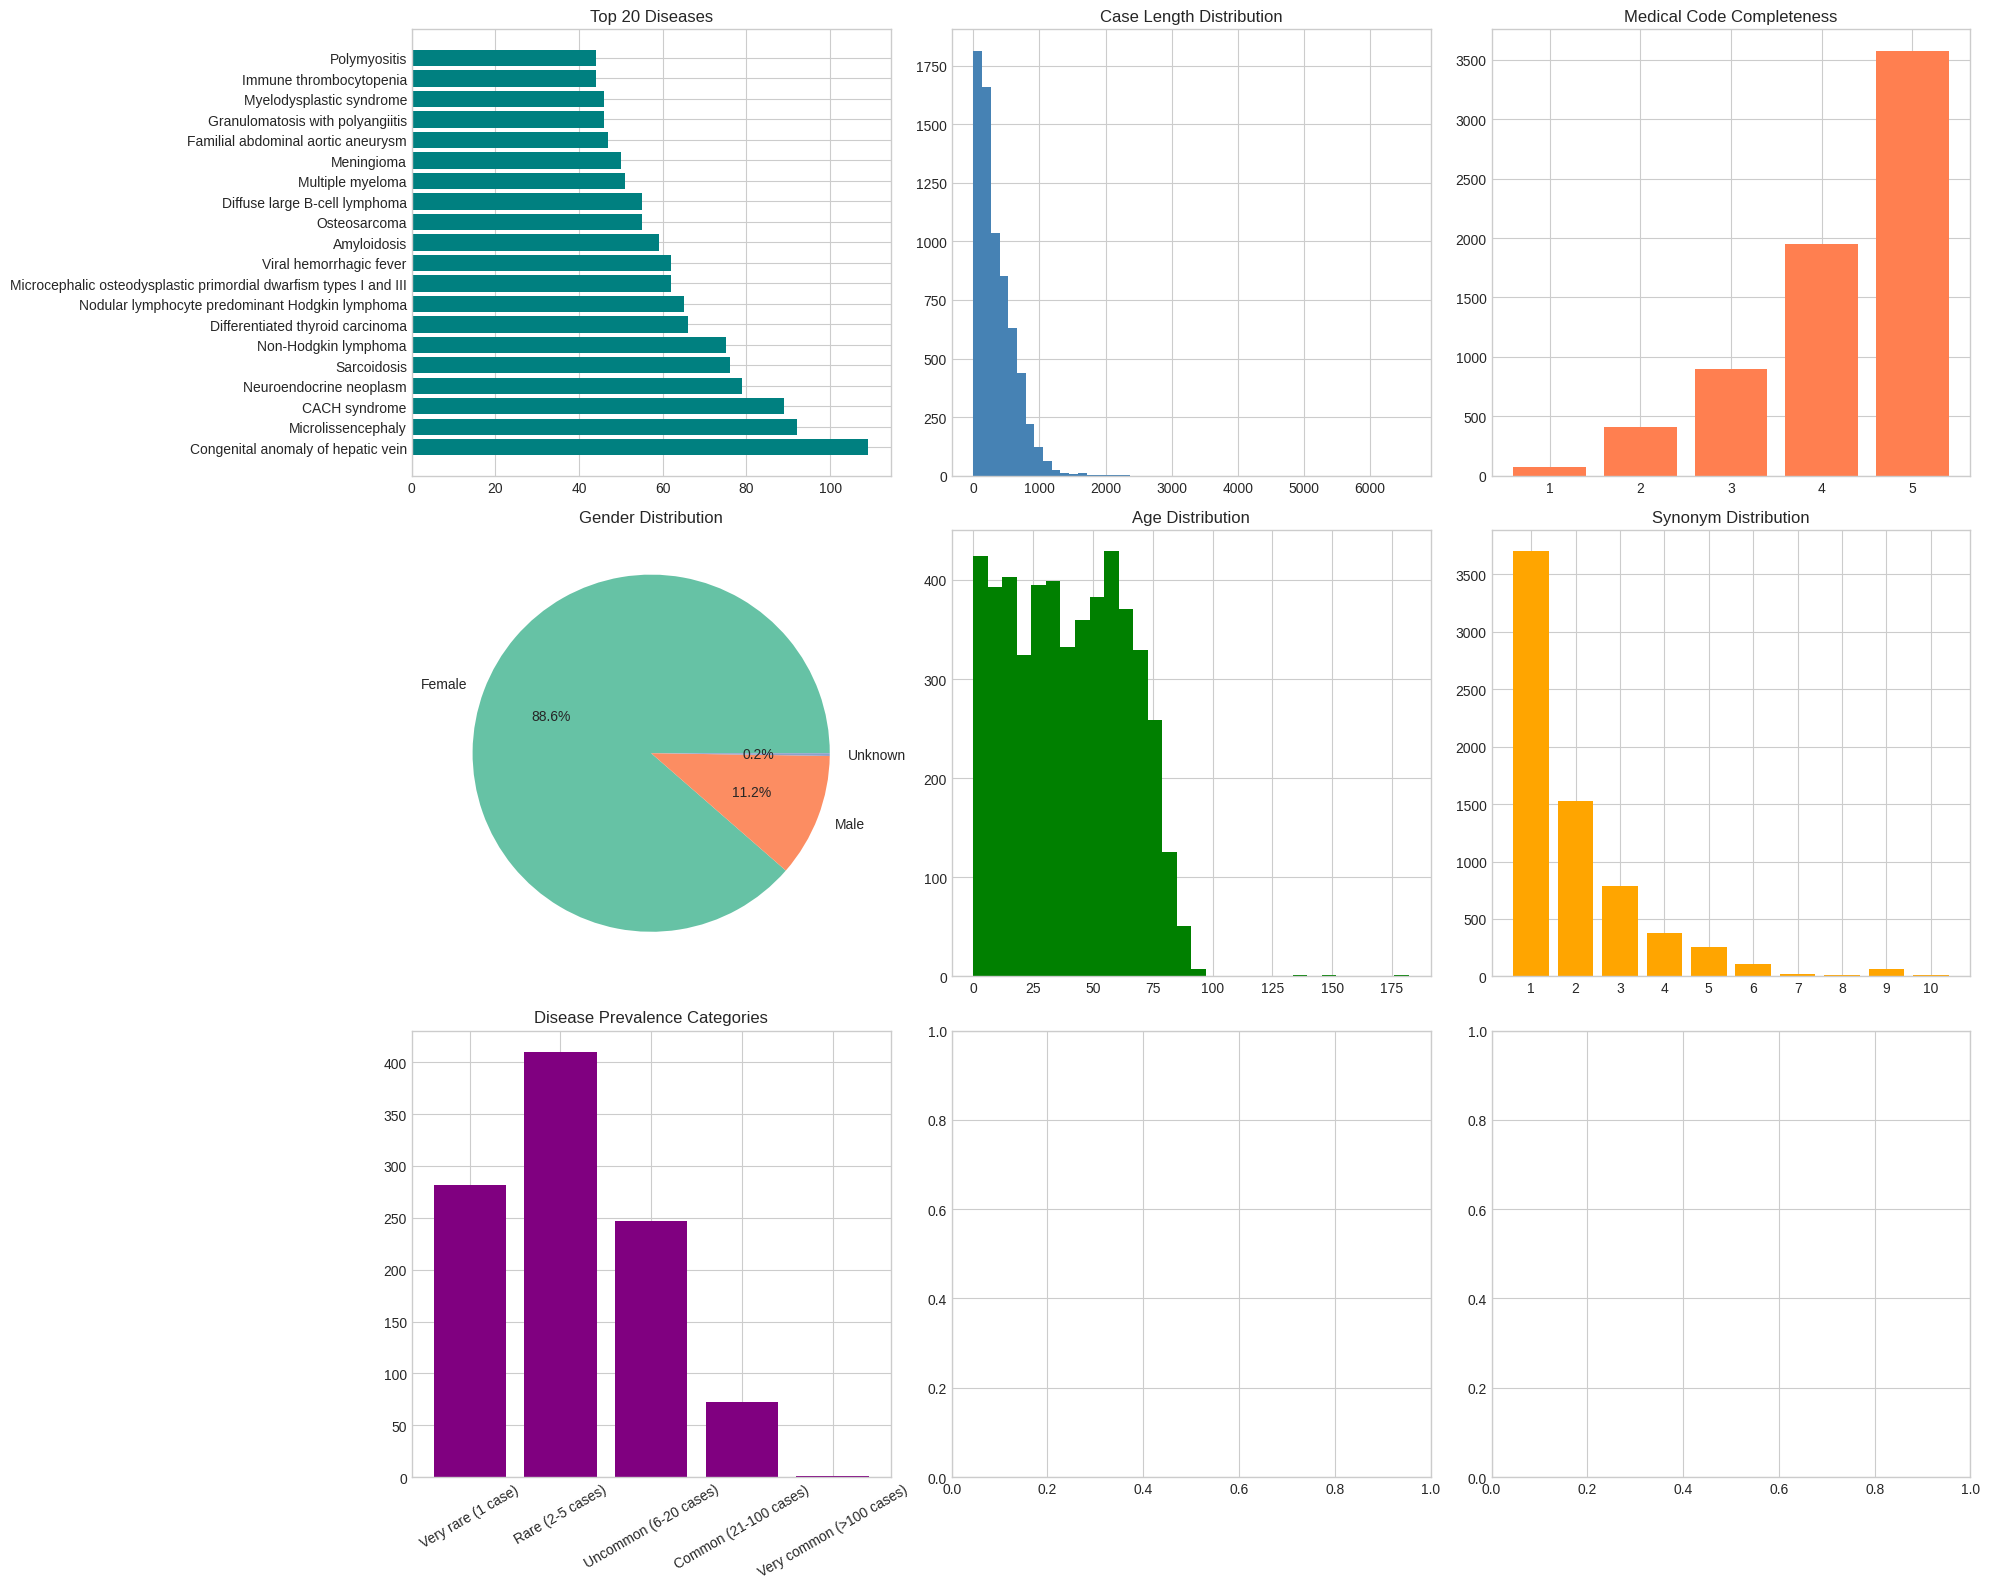

In [9]:
fig, axes = plt.subplots(3,3,figsize=(20,16))

axes[0,0].barh(top_diseases.index, top_diseases.values, color='teal')
axes[0,0].set_title("Top 20 Diseases")

axes[0,1].hist(df['summary_words'], bins=50, color='steelblue')
axes[0,1].set_title("Case Length Distribution")

cc = df['code_completeness'].value_counts().sort_index()
axes[0,2].bar(cc.index, cc.values, color='coral')
axes[0,2].set_title("Medical Code Completeness")

gcounts = df['patient_gender'].value_counts()
axes[1,0].pie(gcounts.values, labels=gcounts.index, autopct='%1.1f%%')
axes[1,0].set_title("Gender Distribution")

age_data = df['patient_age'].dropna()
axes[1,1].hist(age_data, bins=30, color='green')
axes[1,1].set_title("Age Distribution")

if 'synonym_count' in df.columns:
    syn_dist = df[df['synonym_count']>0]['synonym_count'].value_counts().sort_index().head(10)
    axes[1,2].bar(syn_dist.index.astype(str), syn_dist.values, color='orange')
    axes[1,2].set_title("Synonym Distribution")

axes[2,0].bar(prevalence_cats.keys(), prevalence_cats.values(), color='purple')
axes[2,0].set_title("Disease Prevalence Categories")
axes[2,0].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## SIMPLIFIED ML BENCHMARKING

In [10]:
valid_diseases = disease_counts[disease_counts>=config.MIN_SAMPLES_PER_DISEASE].index
df_ml = df[df['Disease'].isin(valid_diseases)].copy()
X_text = df_ml['clean_text'].tolist()
y = df_ml['Disease']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2), stop_words='english')
X_tfidf = vectorizer.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_encoded, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y_encoded
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
        'report': classification_report(y_test, y_pred)
    }
    print(f"{name} Accuracy: {results[name]['accuracy']:.3f}, Weighted F1: {results[name]['f1_weighted']:.3f}")


Logistic Regression Accuracy: 0.152, Weighted F1: 0.097
Random Forest Accuracy: 0.183, Weighted F1: 0.136


## TOP TF-IDF KEYWORDS + FEATURE IMPORTANCE


Top 20 TF-IDF Keywords:
patient              394.11
fig                  244.74
mg                   243.65
showed               237.59
normal               214.99
figure               205.61
revealed             200.80
left                 197.44
right                187.67
years                183.06
day                  179.75
year                 175.51
old                  173.20
blood                170.40
months               161.25
treatment            157.02
history              156.98
examination          156.52
age                  155.88
patients             151.43


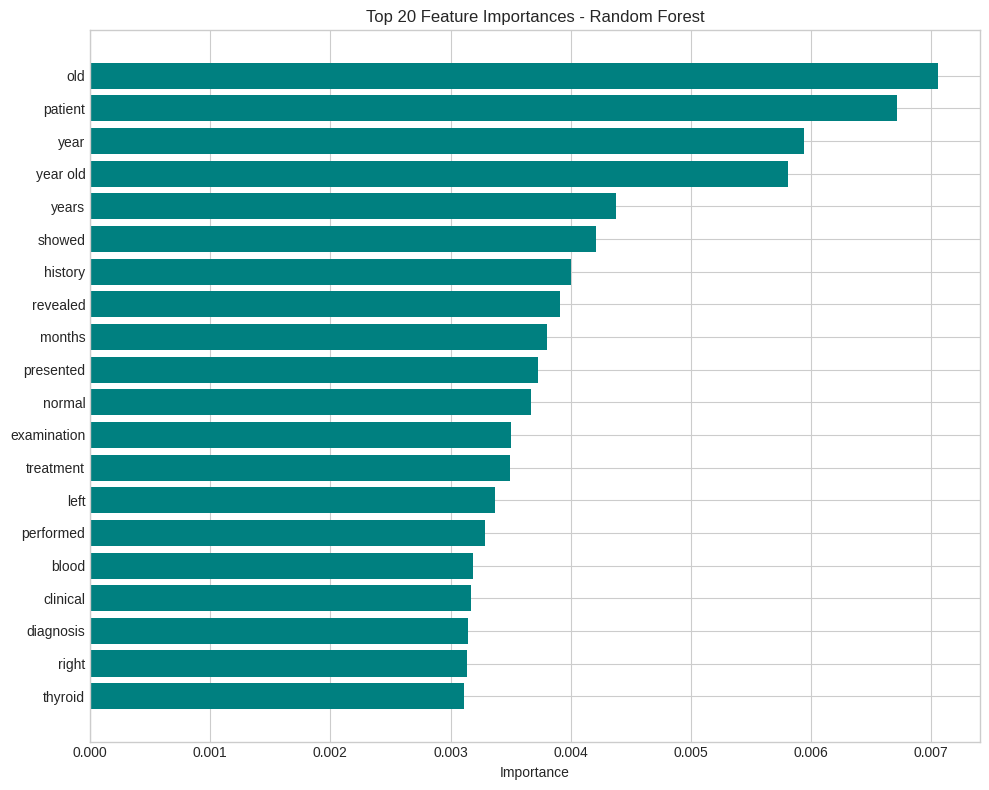

In [11]:
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = X_tfidf.sum(axis=0).A1
top_idx = tfidf_scores.argsort()[-20:][::-1]
top_terms = [(feature_names[i], tfidf_scores[i]) for i in top_idx]

print("\nTop 20 TF-IDF Keywords:")
for term, score in top_terms:
    print(f"{term:20s} {score:.2f}")

# Feature importance visualization for Random Forest
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    top_idx = importances.argsort()[-20:][::-1]
    top_features = [(feature_names[i], importances[i]) for i in top_idx]
    
    features, imp_vals = zip(*top_features)
    plt.figure(figsize=(10,8))
    plt.barh(features, imp_vals, color='teal')
    plt.title("Top 20 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## EXPORT RESULTS

In [12]:
df.to_csv('zebramap_enhanced_dataset.csv', index=False)
pd.DataFrame(results).T.to_csv('zebramap_model_performance.csv')
df['Disease'].value_counts().reset_index().to_csv('zebramap_disease_statistics.csv', index=False)

with open('zebramap_analysis_report.txt','w') as f:
    f.write(f"ZEBRAMAP ANALYSIS REPORT - {datetime.now().strftime('%B %d, %Y')}\n")
    f.write("="*60+"\n")
    f.write(f"Total Cases: {len(df):,}\n")
    f.write(f"Unique Diseases: {df['Disease'].nunique():,}\n")
    f.write(f"Top Disease: {df['Disease'].value_counts().idxmax()}\n")
    best_model = max(results, key=lambda x: results[x]['accuracy'])
    f.write(f"Best Model: {best_model} (Acc: {results[best_model]['accuracy']:.3f}, F1-weighted: {results[best_model]['f1_weighted']:.3f})\n")

print("\nAll exports created:\n - zebramap_enhanced_dataset.csv\n - zebramap_model_performance.csv\n - zebramap_disease_statistics.csv\n - zebramap_analysis_report.txt")


All exports created:
 - zebramap_enhanced_dataset.csv
 - zebramap_model_performance.csv
 - zebramap_disease_statistics.csv
 - zebramap_analysis_report.txt
